# Occupational Mental Fatigue Prediction Model

## Random Forest Classifier

***Library Imports***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

***Dataset Initialization***

In [2]:
# Loading the dataset
mefar_data = pd.read_csv('../Datasets/MEFAR_MID.csv')
mefar_data.head()  #Displays the first 5 rows of the dataset              

,BVP,EDA,TEMP,AccX,AccY,AccZ,HR,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2,Attention,Meditation,class
0,-0.150426,0.026215,0.778824,-0.325490,0.019608,0.388235,0.357959,0.019138,0.082949,0.017362,0.020516,0.001465,0.002844,0.021253,0.044376,0.484848,0.090909,1.0
1,-0.145506,0.026215,0.778824,-0.333333,-0.003922,0.388235,0.357959,0.019138,0.082949,0.017362,0.020516,0.001465,0.002844,0.021253,0.044376,0.484848,0.090909,1.0
2,-0.135576,0.026215,0.778824,-0.349020,-0.035294,0.333333,0.357959,0.019138,0.082949,0.017362,0.020516,0.001465,0.002844,0.021253,0.044376,0.484848,0.090909,1.0
3,-0.121047,0.026215,0.778824,-0.380392,-0.027451,0.356863,0.357959,0.019138,0.082949,0.017362,0.020516,0.001465,0.002844,0.021253,0.044376,0.484848,0.090909,1.0
4,-0.103369,0.026215,0.778824,-0.411765,-0.011765,0.411765,0.357959,0.019138,0.082949,0.017362,0.020516,0.001465,0.002844,0.021253,0.044376,0.484848,0.090909,1.0


***Correlation Matrix***

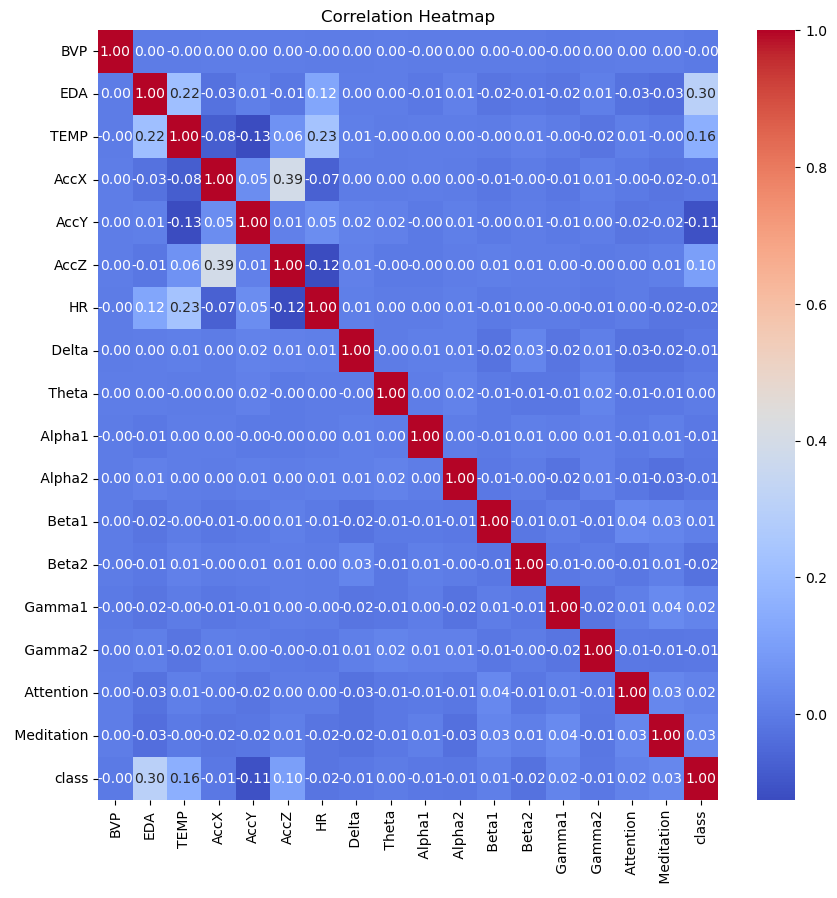

In [3]:
plt.figure(figsize=(10, 10))
sns.heatmap(mefar_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')    
plt.show()

***Feature Distribution***

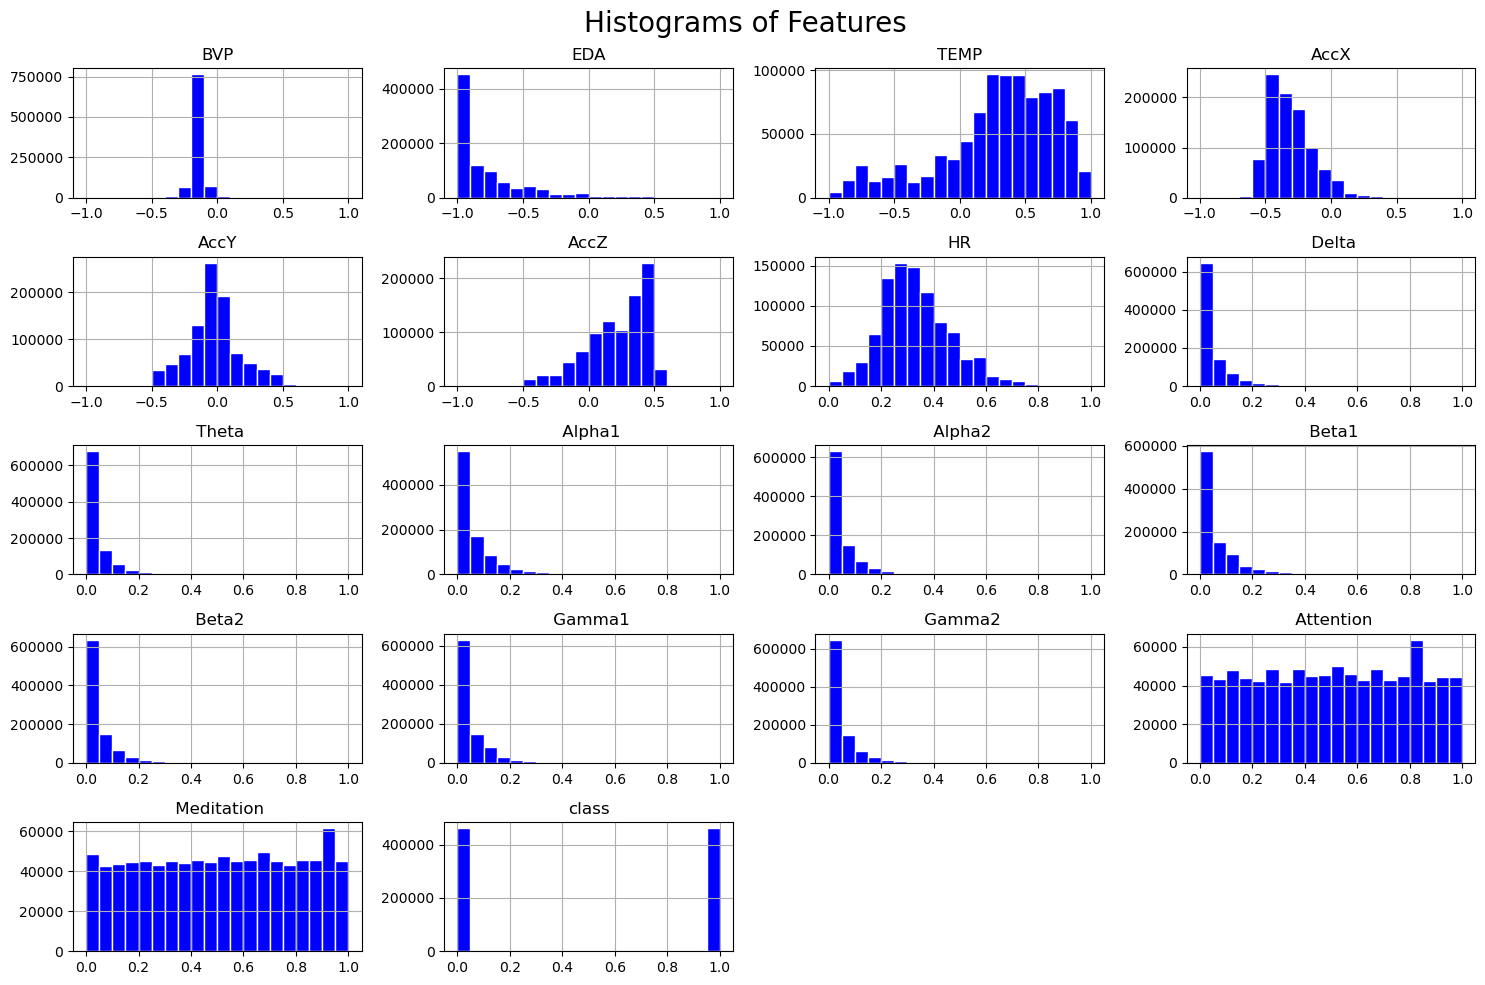

In [4]:
mefar_data.hist(figsize=(15, 10), bins=20, color='blue', edgecolor='white')
plt.suptitle('Histograms of Features', fontsize=20) 
plt.tight_layout()
plt.show()

***Data Preprocessing***

In [5]:
#Storing Input Features
X = mefar_data.drop('class', axis=1)  #Removes the Fatigue Class target variable 

#Storing Target Variables
y = mefar_data['class']                   #Creates a new DataFrame with the Fatigue Class target variable

***Feature Scaling***

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  #Standardizing the input features

***Data Splitting into Training and Testing Sets***

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42)

***Model Training***

In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) 
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluating the Random Forest Classifier Model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f'Random Forest Accuracy: {rf_accuracy:.2f}')
print(f'Random Forest F1 Score: {rf_f1:.2f}')

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 1.00
Random Forest F1 Score: 1.00

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     92491
         1.0       1.00      1.00      1.00     92169

    accuracy                           1.00    184660
   macro avg       1.00      1.00      1.00    184660
weighted avg       1.00      1.00      1.00    184660


Confusion Matrix:
 [[92490     1]
 [   10 92159]]


***Hyperparameter Tuning***

In [9]:
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


pipeline = Pipeline([
    ('scaler', StandardScaler()),              # Feature scaling
    ('rf_model', RandomForestClassifier(random_state=42))
])


cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Define hyperparameter grid
param_grid = {
    'rf_model__n_estimators': [100, 200],
    'rf_model__max_depth': [5, 10, None],
    'rf_model__min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    cv = cv,
    scoring = 'f1',
    n_jobs = -1,
    verbose = 2)

# Fit to training data
grid_search.fit(X_train, y_train)

# Extract and evaluate best model
best_clf = grid_search.best_estimator_ # Changed variable name to clf (classifier)
y_pred = best_clf.predict(X_test)

print("Best Parameters:", grid_search.best_params_)

print("Best F1 Score from CV:", grid_search.best_score_)
print("F1 Score on Test Set:", f1_score(y_test, y_pred))
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred)) 
print("\nClassification Report on Test Set:\n", classification_report(y_test, y_pred)) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'rf_model__max_depth': None, 'rf_model__min_samples_split': 2, 'rf_model__n_estimators': 100}
Best F1 Score from CV: 0.999948543807515
F1 Score on Test Set: 0.9999403240944181
Accuracy on Test Set: 0.9999404310624932

Classification Report on Test Set:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     92491
         1.0       1.00      1.00      1.00     92169

    accuracy                           1.00    184660
   macro avg       1.00      1.00      1.00    184660
weighted avg       1.00      1.00      1.00    184660



### Visualize Feature Importances

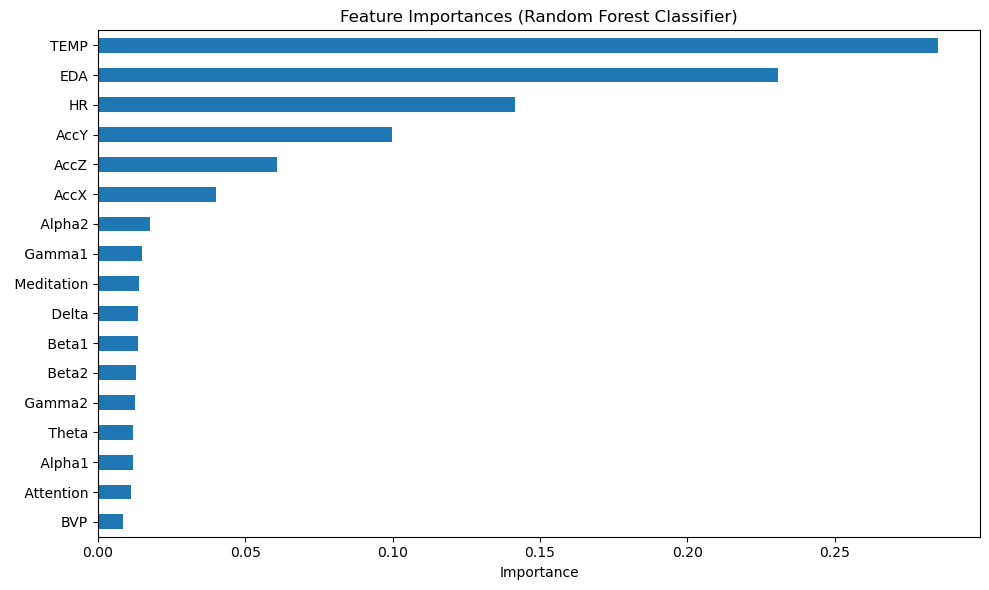

In [10]:
rf_classifier = grid_search.best_estimator_.named_steps['rf_model']

original_feature_names = X.columns

importances = rf_classifier.feature_importances_


pd.Series(importances, index=original_feature_names).sort_values().plot(
    kind='barh', figsize=(10, 6)
)
plt.title("Feature Importances (Random Forest Classifier)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Removing Low Impact Features

In [11]:
low_impact_features = [
    ' Attention', ' Alpha1', ' Gamma2', ' Theta', ' Beta2',
    ' Delta', ' Meditation', ' Beta1', ' Gamma1', ' Alpha2']

X_reduced = X.drop(columns=low_impact_features)

### Updating the model

In [12]:
from sklearn.preprocessing import FunctionTransformer
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42)

### Model Building and Training

In [13]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10],
    'model__min_samples_split': [2, 5]
}

grid = GridSearchCV(pipeline, 
                    param_grid, 
                    cv=5, 
                    scoring='f1', 
                    n_jobs=-1,    
                    verbose=2)

grid.fit(X_train, y_train)

print("Best Parameters found by GridSearchCV:")
print(grid.best_params_)

print("\nBest F1 Score (during cross-validation):")
print(f"{grid.best_score_:.4f}")

# Make predictions on the test set with the best model
y_pred = grid.predict(X_test)

print("\nClassification Report on the Test Set:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters found by GridSearchCV:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best F1 Score (during cross-validation):
0.9997

Classification Report on the Test Set:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     92491
         1.0       1.00      1.00      1.00     92169

    accuracy                           1.00    184660
   macro avg       1.00      1.00      1.00    184660
weighted avg       1.00      1.00      1.00    184660



Confusion Matrix:
[[92485     6]
 [   30 92139]]


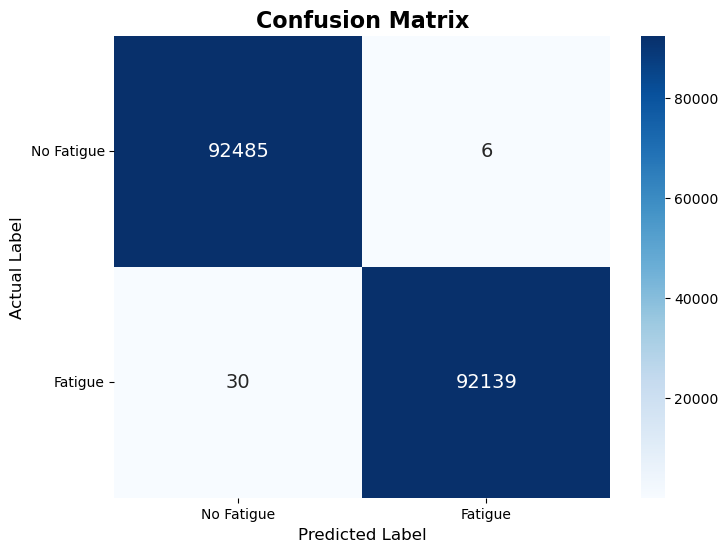

In [14]:
cm = confusion_matrix(y_test, y_pred)

class_labels = ['No Fatigue', 'Fatigue']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            annot_kws={"size": 14})

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)

plt.savefig('rf_confusion_matrix.png')

print("Confusion Matrix:")
print(cm)

### Save Tuned Model

In [15]:
import joblib
joblib.dump(grid.best_estimator_, 'Occupational Mental Fatigue Model_RF_MID.pkl')

['Occupational Mental Fatigue Model_RF_MID.pkl']